# Testing MLP on digit classification

In [1]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()

digits = load_digits()

X = digits.data / 16
y = digits.target.reshape(len(X), 1)
y = lb.fit_transform(y)

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Features shape: (1797, 64)
Labels shape: (1797, 10)


In [2]:
from microtorch.data import random_split, DataLoader

(X_train, y_train), (X_test, y_test) = random_split(
    X, y,
    ratios=[0.8, 0.2],
    seed=42,
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1438, 64)
(359, 64)
(1438, 10)
(359, 10)


In [3]:
BATCH_SIZE=20

train_loader = DataLoader(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
)

test_loader = DataLoader(
    X_test, y_test,
    batch_size=BATCH_SIZE,
)

In [4]:
from microtorch.models import MLP
from microtorch import nn
from microtorch.optimizers import SGD
from microtorch.functions import softmax, cross_entropy_loss
from tqdm import tqdm
import numpy as np

LR = 0.05
epochs = 10

model = MLP(
    in_size=64,
    hidden_layers=[32],
    out_size=10,
    activations=['relu']
)

optimizer = SGD(model, lr=LR)
loss_fn = cross_entropy_loss
def acc_fn(y_pred, y_true):
    y_pred = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_true, axis=1)
    return (y_pred == y_true).mean()

loss_hist = []
train_acc_hist = []
test_acc_hist = []

for e in range(epochs):
    train_loss = 0
    train_acc = 0
    for X, y in tqdm(train_loader, f"Epoch #{e}"):
        optimizer.zero_grad()
        
        y_pred = model(X)
        
        y_pred = softmax(y_pred)
    
        l = loss_fn(y_pred, y)

        train_loss += l.val

        l.backprop()
        optimizer.step()

        train_acc += acc_fn(y_pred, y) * len(y)

    train_loss /= len(train_loader)
    train_acc /= len(X_train)
    test_acc = acc_fn(model(X_test), y_test)

    loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc)

    print(f"Epoch #{e}: Loss {train_loss} | Train Accuracy {train_acc:.2f} | Test Accuracy {test_acc:.2f}")

Epoch #0: 100%|███████████████████████████████████████████████████████████████████████████████| 72/72 [01:33<00:00,  1.29s/it]


Epoch #0: Loss 2.1164771081147045 | Train Accuracy 0.33 | Test Accuracy 0.64


Epoch #1: 100%|███████████████████████████████████████████████████████████████████████████████| 72/72 [01:35<00:00,  1.32s/it]


Epoch #1: Loss 1.5685797590108848 | Train Accuracy 0.71 | Test Accuracy 0.84


Epoch #2: 100%|███████████████████████████████████████████████████████████████████████████████| 72/72 [01:43<00:00,  1.44s/it]


...

Epoch #7: Loss 0.28425511991189306 | Train Accuracy 0.94 | Test Accuracy 0.93


Epoch #8: 100%|███████████████████████████████████████████████████████████████████████████████| 72/72 [01:48<00:00,  1.50s/it]


Epoch #8: Loss 0.2508704722041616 | Train Accuracy 0.95 | Test Accuracy 0.93


Epoch #9: 100%|███████████████████████████████████████████████████████████████████████████████| 72/72 [01:39<00:00,  1.39s/it]


Epoch #9: Loss 0.2270005210165896 | Train Accuracy 0.95 | Test Accuracy 0.92


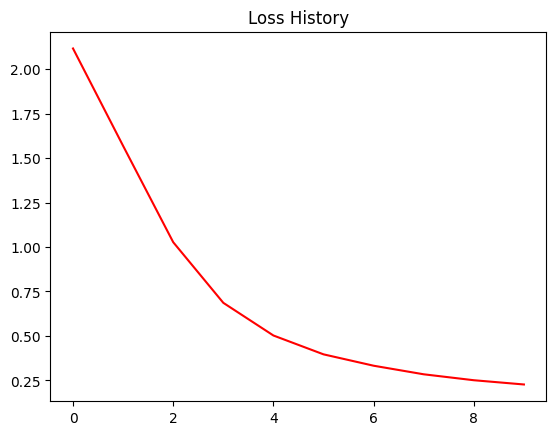

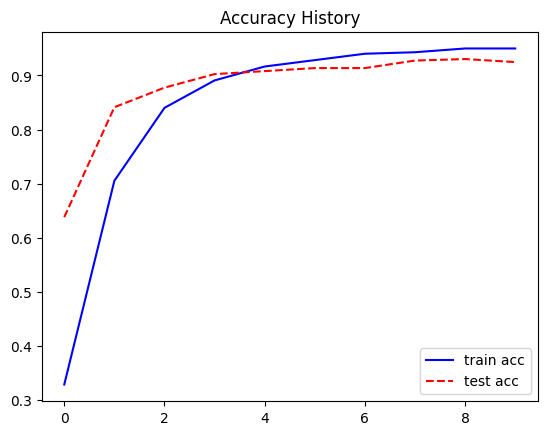

In [5]:
import matplotlib.pyplot as plt

eps = np.arange(epochs)

plt.title('Loss History')
plt.plot(eps, loss_hist, 'r-')
plt.show()

plt.title('Accuracy History')
plt.plot(eps, train_acc_hist, 'b-', label='train acc')
plt.plot(eps, test_acc_hist, 'r--', label='test acc')
plt.legend(loc="lower right")
plt.show()